# Prediksi Sentimen Saham IDX80 Berdasarkan Artikel Berita Menggunakan Metode Long Short-Term Memory

Notebook ini disusun mengikuti alur laporan skripsi pada BAB III dan BAB IV, yaitu Business Understanding, Data Understanding, Data Preparation, Modeling, Evaluation, dan Deployment. Fokus penelitian adalah klasifikasi sentimen artikel berita ekonomi berbahasa Indonesia terhadap saham IDX80 menggunakan metode Long Short-Term Memory (LSTM).

Label sentimen diselaraskan dengan laporan menjadi tiga kelas: `Positif`, `Netral`, dan `Negatif`. Jika dataset masih memakai label `Naik`, `Turun`, dan `Netral`, notebook akan mengubahnya menjadi `Positif`, `Negatif`, dan `Netral`.


## Instalasi Library

Jalankan sel berikut jika library belum tersedia di environment lokal atau Google Colab.


In [7]:
# Jalankan jika diperlukan:
!pip install pandas numpy scikit-learn tensorflow Sastrawi matplotlib


  Using cached numpy-2.0.2-cp311-cp311-win_amd64.whl.metadata (59 kB)
Using cached numpy-2.0.2-cp311-cp311-win_amd64.whl (15.9 MB)

   ---------------------------------------- 0/2 [Sastrawi]
   ---------------------------------------- 0/2 [Sastrawi]
   ---------------------------------------- 0/2 [Sastrawi]
   ---------------------------------------- 0/2 [Sastrawi]
  Attempting uninstall: numpy
   ---------------------------------------- 0/2 [Sastrawi]
    Found existing installation: numpy 2.3.5
   ---------------------------------------- 0/2 [Sastrawi]
   -------------------- ------------------- 1/2 [numpy]
    Uninstalling numpy-2.3.5:
   -------------------- ------------------- 1/2 [numpy]
      Successfully uninstalled numpy-2.3.5
   -------------------- ------------------- 1/2 [numpy]
   -------------------- ------------------- 1/2 [numpy]
   -------------------- ------------------- 1/2 [numpy]
   -------------------- ------------------- 1/2 [numpy]
   -------------------- ------

  You can safely remove it manually.
  You can safely remove it manually.

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Import Library


In [8]:
import json
import pickle
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import LSTM, Dense, Dropout, Embedding, Input
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

try:
    from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
    from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
except ImportError:
    StemmerFactory = None
    StopWordRemoverFactory = None


## Konfigurasi Penelitian

Konfigurasi ini disamakan dengan kebutuhan laporan dan aplikasi Streamlit. File artefak yang dihasilkan dapat langsung dipakai oleh `app.py`.


In [9]:
DATASET_PATH = Path('idx80.csv')
ARTIFACT_DIR = Path('artifacts')
MODEL_PATH = ARTIFACT_DIR / 'lstm_sentiment_model.keras'
TOKENIZER_PATH = ARTIFACT_DIR / 'tokenizer.pkl'
LABEL_ENCODER_PATH = ARTIFACT_DIR / 'label_encoder.pkl'
CONFIG_PATH = ARTIFACT_DIR / 'config.json'

TITLE_COLUMN = 'judul'
BODY_COLUMN = 'isi_berita'
LABEL_COLUMN = 'sentiment'
STANDARD_LABEL_COLUMN = 'sentiment_standard'

MAX_WORDS = 10_000
MAX_LEN = 100
TEST_SIZE = 0.2
RANDOM_STATE = 42
EPOCHS = 20
BATCH_SIZE = 32
LSTM_UNITS = 128
EMBEDDING_DIM = 128

LABEL_NORMALIZATION = {
    'naik': 'Positif',
    'positif': 'Positif',
    'positive': 'Positif',
    'turun': 'Negatif',
    'negatif': 'Negatif',
    'negative': 'Negatif',
    'netral': 'Netral',
    'neutral': 'Netral',
}


# BAB III - Metodologi Penelitian

## Business Understanding

Tujuan penelitian adalah membangun sistem yang mampu mendeteksi polaritas sentimen berita ekonomi terkait emiten IDX80 secara otomatis. Sistem ini diharapkan membantu proses analisis investor karena volume berita yang besar sulit dianalisis secara manual.


## Data Understanding

Data yang digunakan berupa artikel berita ekonomi berbahasa Indonesia. Atribut utama terdiri dari `judul`, `isi_berita`, dan `sentiment`. Kolom `judul` dan `isi_berita` menjadi fitur teks, sedangkan `sentiment` menjadi target klasifikasi.


In [10]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f'Dataset tidak ditemukan: {DATASET_PATH.resolve()}. '
        'Letakkan file idx80.csv di folder yang sama dengan notebook ini.'
    )

try:
    df = pd.read_csv(DATASET_PATH, encoding='latin1')
except UnicodeDecodeError:
    df = pd.read_csv(DATASET_PATH, encoding='utf-8')

df.columns = [str(column).strip().lower() for column in df.columns]
required_columns = {TITLE_COLUMN, BODY_COLUMN, LABEL_COLUMN}
missing_columns = required_columns.difference(df.columns)

if missing_columns:
    raise ValueError(f'Kolom wajib belum ada di dataset: {sorted(missing_columns)}')

print('Total data:', len(df))
df.head()


Total data: 255


,tanggal,judul,isi_berita,link,sentiment
0,27/1/2026,Rebalancing BEI: Emiten Prajogo BREN Masuk LQ4...,Bursa Efek Indonesia (BEI) mengumumkan hasil e...,https://stockbit.com/post/27312904,Netral
1,18/12/2025,"Standar Global Masuk BEI: IDX30, LQ45, dan IDX...",PT Bursa Efek Indonesia (BEI) memperkuat kredi...,https://stockbit.com/post/25109790,Netral
2,5/12/2025,Tawarkan Akses Likuiditas - BRIDS Hadirkan Lay...,Jakarta - BRI Danareksa Sekuritas (BRIDS) bers...,https://stockbit.com/post/24427147,Netral
3,28/10/2025,Bumi Resources (BUMI) Hingga DSSA Jadi Pendata...,Bursa Efek Indonesia (BEI) merilis hasil evalu...,https://stockbit.com/post/22791419,Netral
4,28/10/2025,"Evaluasi indeks terbaru: BUMI, DSSA, EMTK masu...",JAKARTA  Bursa Efek Indonesia (BEI) mengumumk...,https://stockbit.com/post/22787813,Netral


In [11]:
print('Informasi dataset:')
df.info()

print('\nJumlah missing value:')
display(df[[TITLE_COLUMN, BODY_COLUMN, LABEL_COLUMN]].isna().sum())

print('\nDistribusi label asli:')
display(df[LABEL_COLUMN].value_counts())


Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   tanggal     255 non-null    object
 1   judul       255 non-null    object
 2   isi_berita  255 non-null    object
 3   link        254 non-null    object
 4   sentiment   255 non-null    object
dtypes: object(5)
memory usage: 10.1+ KB

Jumlah missing value:


judul         0
isi_berita    0
sentiment     0
dtype: int64


Distribusi label asli:


sentiment
Positif    126
Netral      69
Negatif     60
Name: count, dtype: int64

## Data Preparation

Tahapan data preparation mengikuti laporan: case folding, cleansing, tokenizing, stopword removal, stemming, word embedding melalui Embedding Layer, dan padding. Tokenizing dan word embedding dilakukan oleh `Tokenizer` serta `Embedding` pada TensorFlow/Keras.


In [12]:
def normalize_sentiment_label(label):
    normalized = str(label).strip().lower()
    return LABEL_NORMALIZATION.get(normalized, str(label).strip().title())


if StopWordRemoverFactory is not None:
    stopword_remover = StopWordRemoverFactory().create_stop_word_remover()
else:
    stopword_remover = None
    print('Sastrawi StopWordRemover belum tersedia. Stopword removal dilewati.')

if StemmerFactory is not None:
    stemmer = StemmerFactory().create_stemmer()
else:
    stemmer = None
    print('Sastrawi Stemmer belum tersedia. Stemming dilewati.')


def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    if stopword_remover is not None:
        text = stopword_remover.remove(text)

    if stemmer is not None:
        text = stemmer.stem(text)

    return text


df = df.dropna(subset=[LABEL_COLUMN]).copy()
df[STANDARD_LABEL_COLUMN] = df[LABEL_COLUMN].apply(normalize_sentiment_label)
df['text'] = df[TITLE_COLUMN].fillna('').astype(str) + ' ' + df[BODY_COLUMN].fillna('').astype(str)
df['clean_text'] = df['text'].apply(clean_text)
df = df[df['clean_text'].str.len() > 0].reset_index(drop=True)

print('Total data setelah preprocessing:', len(df))
print('Distribusi label standar:')
display(df[STANDARD_LABEL_COLUMN].value_counts())
df[[TITLE_COLUMN, BODY_COLUMN, LABEL_COLUMN, STANDARD_LABEL_COLUMN, 'clean_text']].head()


Total data setelah preprocessing: 255
Distribusi label standar:


sentiment_standard
Positif    126
Netral      69
Negatif     60
Name: count, dtype: int64

,judul,isi_berita,sentiment,sentiment_standard,clean_text
0,Rebalancing BEI: Emiten Prajogo BREN Masuk LQ4...,Bursa Efek Indonesia (BEI) mengumumkan hasil e...,Netral,Netral,rebalancing bei emiten prajogo bren masuk lq i...
1,"Standar Global Masuk BEI: IDX30, LQ45, dan IDX...",PT Bursa Efek Indonesia (BEI) memperkuat kredi...,Netral,Netral,standar global masuk bei idx lq idx selaras io...
2,Tawarkan Akses Likuiditas - BRIDS Hadirkan Lay...,Jakarta - BRI Danareksa Sekuritas (BRIDS) bers...,Netral,Netral,tawar akses likuiditas brids hadir layan gadai...
3,Bumi Resources (BUMI) Hingga DSSA Jadi Pendata...,Bursa Efek Indonesia (BEI) merilis hasil evalu...,Netral,Netral,bumi resources bumi hingga dssa jadi datang ba...
4,"Evaluasi indeks terbaru: BUMI, DSSA, EMTK masu...",JAKARTA  Bursa Efek Indonesia (BEI) mengumumk...,Netral,Netral,evaluasi indeks baru bumi dssa emtk masuk lq j...


In [13]:
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df[STANDARD_LABEL_COLUMN].astype(str))

label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print('Mapping label:', label_mapping)


Mapping label: {'Negatif': np.int64(0), 'Netral': np.int64(1), 'Positif': np.int64(2)}


In [14]:
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(df['clean_text'])

sequences = tokenizer.texts_to_sequences(df['clean_text'])
X = pad_sequences(sequences, maxlen=MAX_LEN)
y = df['label'].values

print('Shape X:', X.shape)
print('Shape y:', y.shape)
print('Jumlah kata unik:', len(tokenizer.word_index))


Shape X: (255, 100)
Shape y: (255,)
Jumlah kata unik: 4365


In [15]:
class_counts = pd.Series(y).value_counts()
stratify_target = y if class_counts.min() >= 2 else None

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=stratify_target,
)

print('Data train:', X_train.shape[0])
print('Data test:', X_test.shape[0])


Data train: 204
Data test: 51


## Modeling

Model utama menggunakan arsitektur Long Short-Term Memory (LSTM). LSTM dipilih karena mampu memproses data berurutan dan mempertahankan konteks informasi jangka panjang pada teks berita. Arsitektur model terdiri dari Input Layer, Embedding Layer, LSTM 128 unit, Dropout, Dense Layer, dan output Softmax untuk klasifikasi multi-kelas.


In [16]:
num_classes = len(label_encoder.classes_)

model = Sequential(
    [
        Input(shape=(MAX_LEN,)),
        Embedding(MAX_WORDS, EMBEDDING_DIM),
        LSTM(LSTM_UNITS),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax'),
    ]
)

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy'],
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,415,811 (5.40 MB)

 Trainable params: 1,415,811 (5.40 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1,
)


Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8884 - loss: 0.4968 - val_accuracy: 0.5490 - val_loss: 1.6001
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8963 - loss: 0.4375 - val_accuracy: 0.5294 - val_loss: 1.0642
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9635 - loss: 0.2624 - val_accuracy: 0.5686 - val_loss: 1.3203
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9387 - loss: 0.2152 - val_accuracy: 0.5490 - val_loss: 1.2733
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9091 - loss: 0.2848 - val_accuracy: 0.4902 - val_loss: 1.2404


## Evaluation

Evaluasi model menggunakan metrik Accuracy, Precision, Recall, F1-Score, dan Confusion Matrix sebagaimana dijelaskan pada laporan.


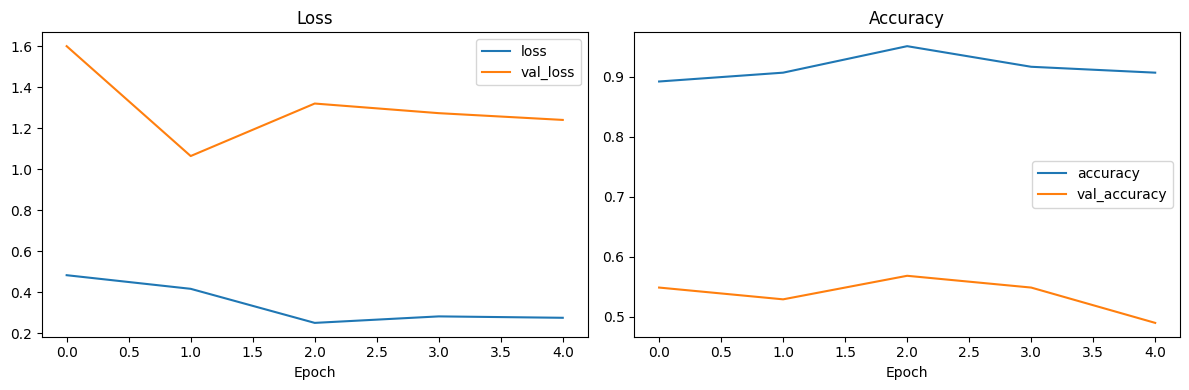

In [28]:
history_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
history_df[['loss', 'val_loss']].plot(ax=axes[0], title='Loss')
history_df[['accuracy', 'val_accuracy']].plot(ax=axes[1], title='Accuracy')

axes[0].set_xlabel('Epoch')
axes[1].set_xlabel('Epoch')
plt.tight_layout()
plt.show()


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
Akurasi data test: 0.4902

Classification report:


,precision,recall,f1-score,support
Negatif,0.000000,0.000000,0.000000,12.000000
Netral,0.000000,0.000000,0.000000,14.000000
Positif,0.490196,1.000000,0.657895,25.000000
accuracy,0.490196,0.490196,0.490196,0.490196
macro avg,0.163399,0.333333,0.219298,51.000000
weighted avg,0.240292,0.490196,0.322497,51.000000


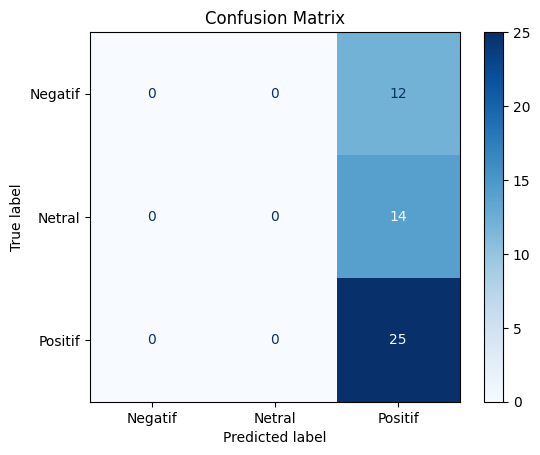

In [19]:
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

accuracy = accuracy_score(y_test, y_pred)
report_dict = classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report_dict).transpose()

print(f'Akurasi data test: {accuracy:.4f}')
print('\nClassification report:')
display(report_df)

cm = confusion_matrix(y_test, y_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
cm_display.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()


## Deployment

Tahap deployment dilakukan dengan menyimpan model dan artefak pendukung agar dapat digunakan pada aplikasi Streamlit. Aplikasi menyediakan halaman Prediksi, Training, Batch CSV, dan Informasi Model sesuai struktur BAB IV laporan.


In [20]:
ARTIFACT_DIR.mkdir(exist_ok=True)
model.save(MODEL_PATH)

with TOKENIZER_PATH.open('wb') as file:
    pickle.dump(tokenizer, file)

with LABEL_ENCODER_PATH.open('wb') as file:
    pickle.dump(label_encoder, file)

config = {
    'max_words': MAX_WORDS,
    'max_len': MAX_LEN,
    'classes': label_encoder.classes_.tolist(),
    'title_column': TITLE_COLUMN,
    'body_column': BODY_COLUMN,
    'label_column': LABEL_COLUMN,
    'standard_label_column': STANDARD_LABEL_COLUMN,
    'training_rows': int(len(df)),
    'test_accuracy': float(accuracy),
    'lstm_units': LSTM_UNITS,
    'embedding_dim': EMBEDDING_DIM,
    'preprocessing': ['case_folding', 'cleansing', 'stopword_removal', 'stemming', 'tokenizing', 'padding'],
}

CONFIG_PATH.write_text(json.dumps(config, indent=2), encoding='utf-8')

print('Model tersimpan di:', MODEL_PATH)
print('Tokenizer tersimpan di:', TOKENIZER_PATH)
print('Label encoder tersimpan di:', LABEL_ENCODER_PATH)
print('Config tersimpan di:', CONFIG_PATH)


Model tersimpan di: artifacts\lstm_sentiment_model.keras
Tokenizer tersimpan di: artifacts\tokenizer.pkl
Label encoder tersimpan di: artifacts\label_encoder.pkl
Config tersimpan di: artifacts\config.json


# BAB IV - Hasil dan Pembahasan

## Contoh Prediksi Sentimen

Sel berikut menunjukkan contoh penggunaan model untuk memprediksi sentimen artikel baru. Hasil prediksi terdiri dari label sentimen, confidence, dan distribusi probabilitas setiap kelas.


In [21]:
def predict_sentiment(text):
    cleaned_text = clean_text(text)
    sequence = tokenizer.texts_to_sequences([cleaned_text])
    padded_sequence = pad_sequences(sequence, maxlen=MAX_LEN)
    probabilities = model.predict(padded_sequence, verbose=0)[0]
    class_index = int(np.argmax(probabilities))
    predicted_label = label_encoder.inverse_transform([class_index])[0]

    probability_table = pd.DataFrame(
        {
            'sentiment': label_encoder.classes_,
            'probability': probabilities,
        }
    ).sort_values('probability', ascending=False)

    return predicted_label, float(probabilities[class_index]), cleaned_text, probability_table


In [22]:
contoh_berita = 'BCA targetkan pertumbuhan penyaluran KPR 6 persen sampai 7 persen pada tahun 2026.'

predicted_label, confidence, cleaned_text, probability_table = predict_sentiment(contoh_berita)

print('Teks bersih:', cleaned_text)
print('Prediksi sentimen:', predicted_label)
print(f'Confidence: {confidence:.2%}')
display(probability_table)


Teks bersih: bca target tumbuh salur kpr persen persen tahun
Prediksi sentimen: Positif
Confidence: 44.31%


,sentiment,probability
2,Positif,0.443071
1,Netral,0.293738
0,Negatif,0.263191


## Load Ulang Model untuk Inferensi

Sel ini opsional. Tujuannya memastikan model yang telah disimpan dapat dimuat ulang dan digunakan pada aplikasi Streamlit tanpa training ulang.


In [ ]:
loaded_model = load_model(MODEL_PATH)

with TOKENIZER_PATH.open('rb') as file:
    loaded_tokenizer = pickle.load(file)

with LABEL_ENCODER_PATH.open('rb') as file:
    loaded_label_encoder = pickle.load(file)

loaded_config = json.loads(CONFIG_PATH.read_text(encoding='utf-8'))
print('Model berhasil dimuat ulang.')
print(loaded_config)
